# 07 — Feature Engineering & ML Pre-processing
**Hotel Booking Demand Dataset**

This notebook prepares the final feature matrix (**X**) and target vector (**y**)
for the Week 3 cancellation prediction model.

Steps performed:
1. Load cleaned dataset and select final feature list
2. Drop data-leakage columns
3. Drop multicollinear columns identified in notebook 05
4. Encode categorical features (Label Encoding + One-Hot Encoding)
5. Validate the final matrix — shape, nulls, dtype uniformity
6. Save `X` and `y` as pickle files for direct model consumption


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pickle
import os

from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})


In [2]:
df = pd.read_csv("../data/cleaned/hotel_cleaned.csv",
                 parse_dates=["reservation_status_date", "arrival_date"])

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Target distribution (is_canceled):")
vc = df["is_canceled"].value_counts()
for v, n in vc.items():
    label = "Cancelled" if v == 1 else "Not Cancelled"
    print(f"  {label} ({v}): {n:,}  ({n/len(df)*100:.2f}%)")


Loaded: 85,598 rows x 36 columns
Target distribution (is_canceled):
  Not Cancelled (0): 61,759  (72.15%)
  Cancelled (1): 23,839  (27.85%)


---
## Step 1 — Remove Data Leakage Columns

The following columns **directly reveal the cancellation outcome** and must be
removed before training any model. Including them would cause data leakage —
perfect in-sample performance that collapses to zero on unseen bookings.


In [3]:
LEAKAGE_COLS = [
    "reservation_status",       # 'Canceled' = is_canceled==1; direct label leak
    "reservation_status_date",  # Date of the cancellation event — post-outcome
    "arrival_date",             # Datetime version already covered by component cols
]

print("Leakage columns removed:")
for col in LEAKAGE_COLS:
    print(f"  - {col:<30} ({df[col].dtype})")

df_clean = df.drop(columns=LEAKAGE_COLS)
print(f"\nShape after leakage removal: {df_clean.shape}")


Leakage columns removed:
  - reservation_status             (str)
  - reservation_status_date        (datetime64[us])
  - arrival_date                   (datetime64[us])

Shape after leakage removal: (85598, 33)


---
## Step 2 — Drop Multicollinear & Redundant Columns

From the correlation analysis in `05_correlation_analysis.ipynb`:
- `stays_in_week_nights` × `total_nights` = r = 0.95 → drop `stays_in_week_nights`
- `stays_in_weekend_nights` × `total_nights` = r = 0.78 → drop `stays_in_weekend_nights`
- `adults` × `total_guests` = r = 0.74 → drop `adults`
- `children`, `babies` → subsumed by `total_guests`

Date-component columns (`arrival_date_year`, `arrival_date_week_number`,
`arrival_date_day_of_month`) are dropped — `arrival_date_month` and `lead_time`
carry the same temporal information with less noise.

High-sentinel/noise columns (`agent`, `company`) are also dropped — filled with
0 and showed near-zero correlation with the target.


In [4]:
MULTICOLLINEAR_COLS = [
    "stays_in_week_nights",       # r=0.95 with total_nights
    "stays_in_weekend_nights",    # r=0.78 with total_nights
    "adults",                     # r=0.74 with total_guests
    "children",                   # subsumed by total_guests
    "babies",                     # subsumed by total_guests
]

DATE_COMPONENT_COLS = [
    "arrival_date_year",
    "arrival_date_week_number",
    "arrival_date_day_of_month",
]

NOISE_COLS = [
    "agent",    # sentinel 0; near-zero correlation with target
    "company",  # sentinel 0; near-zero correlation with target
]

DROP_COLS = MULTICOLLINEAR_COLS + DATE_COMPONENT_COLS + NOISE_COLS

print("Columns dropped in this step:")
for col in DROP_COLS:
    reason = ("multicollinear" if col in MULTICOLLINEAR_COLS
              else "date component" if col in DATE_COMPONENT_COLS
              else "noise/sentinel")
    print(f"  - {col:<38} [{reason}]")

df_clean = df_clean.drop(columns=DROP_COLS)
print(f"\nShape after dropping redundant columns: {df_clean.shape}")


Columns dropped in this step:
  - stays_in_week_nights                   [multicollinear]
  - stays_in_weekend_nights                [multicollinear]
  - adults                                 [multicollinear]
  - children                               [multicollinear]
  - babies                                 [multicollinear]
  - arrival_date_year                      [date component]
  - arrival_date_week_number               [date component]
  - arrival_date_day_of_month              [date component]
  - agent                                  [noise/sentinel]
  - company                                [noise/sentinel]

Shape after dropping redundant columns: (85598, 23)


---
## Step 3 — Define Final Feature List

In [5]:
TARGET_COL = "is_canceled"

# Separate target
y_raw = df_clean[TARGET_COL].copy()
X_raw = df_clean.drop(columns=[TARGET_COL]).copy()

# Categorise features
CATEGORICAL_ENCODE = [
    "hotel", "arrival_date_month", "meal",
    "market_segment", "distribution_channel",
    "deposit_type", "customer_type",
]

CATEGORICAL_DROP = [
    "country",           # 177 unique values — high cardinality; use with care
    "reserved_room_type",  # anonymised letter codes
    "assigned_room_type",  # anonymised letter codes
]

NUMERIC_FEATURES = [c for c in X_raw.columns
                    if c not in CATEGORICAL_ENCODE + CATEGORICAL_DROP]

print("Feature breakdown:")
print(f"  Numerical features       : {len(NUMERIC_FEATURES)}")
print(f"  Categorical (to encode)  : {len(CATEGORICAL_ENCODE)}")
print(f"  Categorical (to drop)    : {len(CATEGORICAL_DROP)}")
print()
print("Numerical features:")
for col in NUMERIC_FEATURES:
    print(f"  {col}")
print()
print("Categorical features to encode:")
for col in CATEGORICAL_ENCODE:
    print(f"  {col:<30} ({X_raw[col].nunique()} unique values)")
print()
print("High-cardinality categorical features DROPPED:")
for col in CATEGORICAL_DROP:
    print(f"  {col:<30} ({X_raw[col].nunique()} unique values)")

X_raw = X_raw.drop(columns=CATEGORICAL_DROP)


Feature breakdown:
  Numerical features       : 12
  Categorical (to encode)  : 7
  Categorical (to drop)    : 3

Numerical features:
  lead_time
  is_repeated_guest
  previous_cancellations
  previous_bookings_not_canceled
  booking_changes
  days_in_waiting_list
  adr
  required_car_parking_spaces
  total_of_special_requests
  total_nights
  total_guests
  revenue_per_booking

Categorical features to encode:
  hotel                          (2 unique values)
  arrival_date_month             (12 unique values)
  meal                           (5 unique values)
  market_segment                 (8 unique values)
  distribution_channel           (5 unique values)
  deposit_type                   (3 unique values)
  customer_type                  (4 unique values)

High-cardinality categorical features DROPPED:
  country                        (177 unique values)
  reserved_room_type             (9 unique values)
  assigned_room_type             (11 unique values)


---
## Step 4 — Encode Categorical Features

**Strategy:**
- **Binary column** (`hotel`): Label Encoding → 0/1
- **Low-cardinality ordinal** (`arrival_date_month`): Ordinal encoding with calendar order
- **Nominal columns** (meal, market_segment, distribution_channel, deposit_type, customer_type):
  One-Hot Encoding with `drop_first=True` to avoid the dummy variable trap

This avoids inflating tree-based models with fake ordinal relationships while keeping
the matrix sparse-free for linear models.


In [6]:
X = X_raw.copy()

# ── Label Encoding: hotel (binary) ──────────────────────────────────────────
le_hotel = LabelEncoder()
X["hotel"] = le_hotel.fit_transform(X["hotel"])
print("hotel encoding:", dict(zip(le_hotel.classes_, le_hotel.transform(le_hotel.classes_))))

# ── Ordinal Encoding: arrival_date_month ────────────────────────────────────
MONTH_ORDER = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
month_map = {m: i+1 for i, m in enumerate(MONTH_ORDER)}
X["arrival_date_month"] = X["arrival_date_month"].map(month_map)
print("arrival_date_month: mapped to 1 (Jan) – 12 (Dec)")
print()

# ── One-Hot Encoding: remaining nominal categoricals ────────────────────────
OHE_COLS = ["meal","market_segment","distribution_channel",
            "deposit_type","customer_type"]

X_before_ohe_cols = X.shape[1]
X = pd.get_dummies(X, columns=OHE_COLS, drop_first=True, dtype=int)

print(f"One-Hot Encoding applied to: {OHE_COLS}")
print(f"  Columns before OHE : {X_before_ohe_cols}")
print(f"  Columns after  OHE : {X.shape[1]}")
print(f"  New dummy columns  : {X.shape[1] - X_before_ohe_cols}")
print()
print("OHE columns created:")
ohe_new = [c for c in X.columns if any(c.startswith(base+"_") for base in OHE_COLS)]
for col in sorted(ohe_new):
    print(f"  {col}")


hotel encoding: {'City Hotel': np.int64(0), 'Resort Hotel': np.int64(1)}
arrival_date_month: mapped to 1 (Jan) – 12 (Dec)

One-Hot Encoding applied to: ['meal', 'market_segment', 'distribution_channel', 'deposit_type', 'customer_type']
  Columns before OHE : 19
  Columns after  OHE : 34
  New dummy columns  : 15

OHE columns created:
  customer_type_Group
  customer_type_Transient
  customer_type_Transient-Party
  deposit_type_Non Refund
  deposit_type_Refundable
  distribution_channel_Direct
  distribution_channel_GDS
  distribution_channel_TA/TO
  distribution_channel_Undefined
  market_segment_Complementary
  market_segment_Corporate
  market_segment_Direct
  market_segment_Groups
  market_segment_Offline TA/TO
  market_segment_Online TA
  market_segment_Undefined
  meal_FB
  meal_HB
  meal_SC
  meal_Undefined


---
## Step 5 — Validate Final Feature Matrix

In [7]:
y = y_raw.copy()

print("=" * 55)
print("  FINAL FEATURE MATRIX SUMMARY")
print("=" * 55)
print(f"  X shape : {X.shape[0]:>7,} rows x {X.shape[1]} columns")
print(f"  y shape : {y.shape[0]:>7,} labels")
print()
print(f"  Target balance:")
print(f"    Not Cancelled (0): {(y==0).sum():>6,}  ({(y==0).mean()*100:.2f}%)")
print(f"    Cancelled     (1): {(y==1).sum():>6,}  ({(y==1).mean()*100:.2f}%)")
print()

# Null check
null_check = X.isnull().sum()
print(f"  Null values in X: {null_check.sum()}")
if null_check.sum() > 0:
    print("  ⚠  Nulls detected:")
    print(null_check[null_check > 0].to_string())
else:
    print("  ✅ No null values — matrix is clean")
print()

# Dtype check
dtype_counts = X.dtypes.value_counts()
print(f"  Data types in X:")
for dtype, count in dtype_counts.items():
    print(f"    {str(dtype):<12}: {count} columns")

all_numeric = all(X.dtypes.apply(lambda d: np.issubdtype(d, np.number)))
print()
print(f"  All columns numeric: {'✅ Yes' if all_numeric else '❌ No — check encoding'}")
print("=" * 55)


  FINAL FEATURE MATRIX SUMMARY
  X shape :  85,598 rows x 34 columns
  y shape :  85,598 labels

  Target balance:
    Not Cancelled (0): 61,759  (72.15%)
    Cancelled     (1): 23,839  (27.85%)

  Null values in X: 0
  ✅ No null values — matrix is clean



  Data types in X:
    int64       : 32 columns
    float64     : 2 columns

  All columns numeric: ✅ Yes


In [8]:
print("Final feature list (X columns):")
print()
for i, col in enumerate(X.columns, 1):
    dtype = str(X[col].dtype)
    print(f"  {i:>2}. {col:<45} [{dtype}]")


Final feature list (X columns):

   1. hotel                                         [int64]
   2. lead_time                                     [int64]
   3. arrival_date_month                            [int64]
   4. is_repeated_guest                             [int64]
   5. previous_cancellations                        [int64]
   6. previous_bookings_not_canceled                [int64]
   7. booking_changes                               [int64]
   8. days_in_waiting_list                          [int64]
   9. adr                                           [float64]
  10. required_car_parking_spaces                   [int64]
  11. total_of_special_requests                     [int64]
  12. total_nights                                  [int64]
  13. total_guests                                  [int64]
  14. revenue_per_booking                           [float64]
  15. meal_FB                                       [int64]
  16. meal_HB                                       [int64]
  1

### Feature Distribution Preview

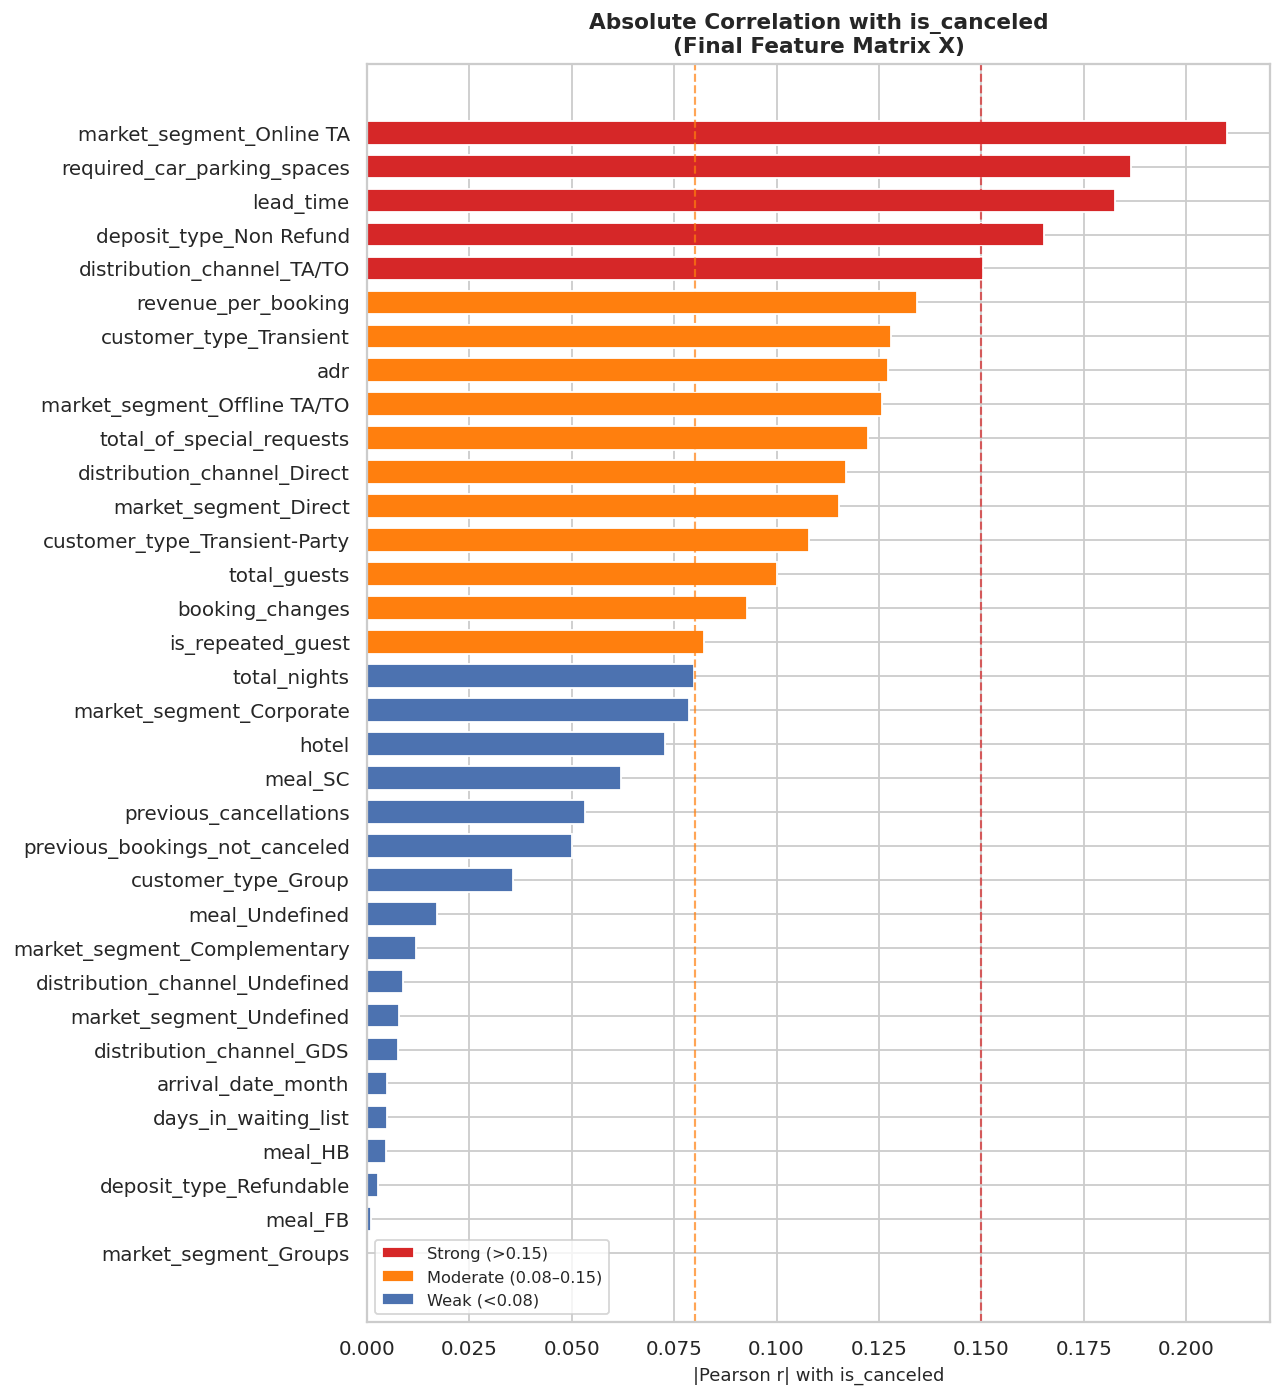

Saved -> visuals/feature_matrix_correlations.png


In [9]:
# Plot absolute correlation of all final features with y
correlations = X.corrwith(y).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, max(5, len(correlations) * 0.32)))

colors = ["#d62728" if v > 0.15 else
          "#ff7f0e" if v > 0.08 else
          "#4C72B0"
          for v in correlations.values]

ax.barh(correlations.index[::-1], correlations.values[::-1],
        color=colors[::-1], edgecolor="white", height=0.7)
ax.axvline(0.15, color="#d62728", linestyle="--", linewidth=1.2,
           alpha=0.7, label="|r| = 0.15")
ax.axvline(0.08, color="#ff7f0e", linestyle="--", linewidth=1.2,
           alpha=0.7, label="|r| = 0.08")

ax.set_title("Absolute Correlation with is_canceled\n(Final Feature Matrix X)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("|Pearson r| with is_canceled", fontsize=10)
ax.legend(fontsize=9)

from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor="#d62728", label="Strong (>0.15)"),
    Patch(facecolor="#ff7f0e", label="Moderate (0.08–0.15)"),
    Patch(facecolor="#4C72B0", label="Weak (<0.08)"),
]
ax.legend(handles=legend_els, fontsize=9)

plt.tight_layout()
plt.savefig("../visuals/feature_matrix_correlations.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved -> visuals/feature_matrix_correlations.png")


---
## Step 6 — Save Preprocessed Feature Matrix & Target Vector

In [10]:
os.makedirs("../data/cleaned", exist_ok=True)

# Save as pickle (preserves column names, dtypes, and bool columns)
X_path = "../data/cleaned/X_features.pkl"
y_path = "../data/cleaned/y_target.pkl"

with open(X_path, "wb") as f:
    pickle.dump(X, f)

with open(y_path, "wb") as f:
    pickle.dump(y, f)

# Also save as CSV for inspection
X.to_csv("../data/cleaned/X_features.csv", index=False)
y.to_csv("../data/cleaned/y_target.csv", index=False)

print(f"✅ Saved pickles:")
print(f"   X -> {X_path}  ({os.path.getsize(X_path)/1024:.1f} KB)")
print(f"   y -> {y_path}  ({os.path.getsize(y_path)/1024:.1f} KB)")
print()
print(f"✅ Saved CSVs:")
print(f"   X -> ../data/cleaned/X_features.csv")
print(f"   y -> ../data/cleaned/y_target.csv")


✅ Saved pickles:
   X -> ../data/cleaned/X_features.pkl  (22739.1 KB)
   y -> ../data/cleaned/y_target.pkl  (669.3 KB)

✅ Saved CSVs:
   X -> ../data/cleaned/X_features.csv
   y -> ../data/cleaned/y_target.csv


In [11]:
# Verify round-trip: reload and confirm shapes match
with open(X_path, "rb") as f:
    X_reload = pickle.load(f)

with open(y_path, "rb") as f:
    y_reload = pickle.load(f)

assert X_reload.shape == X.shape, "X shape mismatch after reload!"
assert y_reload.shape == y.shape, "y shape mismatch after reload!"

print("Round-trip verification:")
print(f"  X reloaded shape : {X_reload.shape}  ✅")
print(f"  y reloaded shape : {y_reload.shape}  ✅")
print(f"  Column names intact: {list(X_reload.columns[:3])} ... ✅")
print()
print("Pre-processing complete — ready for Week 3 modelling.")


Round-trip verification:
  X reloaded shape : (85598, 34)  ✅
  y reloaded shape : (85598,)  ✅
  Column names intact: ['hotel', 'lead_time', 'arrival_date_month'] ... ✅

Pre-processing complete — ready for Week 3 modelling.


---
## Pre-processing Summary

### What Was Done

| Step | Action | Result |
|------|--------|--------|
| Leakage removal | Dropped `reservation_status`, `reservation_status_date`, `arrival_date` | 3 columns removed |
| Multicollinearity | Dropped `stays_in_week_nights`, `stays_in_weekend_nights`, `adults`, `children`, `babies` | 5 columns removed |
| Date components | Dropped `arrival_date_year`, `arrival_date_week_number`, `arrival_date_day_of_month` | 3 columns removed |
| Noise columns | Dropped `agent`, `company` (sentinel 0, near-zero correlation) | 2 columns removed |
| High-cardinality | Dropped `country`, `reserved_room_type`, `assigned_room_type` | 3 columns removed |
| Label Encoding | `hotel` → 0/1 | 1 column encoded |
| Ordinal Encoding | `arrival_date_month` → 1–12 (calendar order) | 1 column encoded |
| One-Hot Encoding | `meal`, `market_segment`, `distribution_channel`, `deposit_type`, `customer_type` | +18 dummy columns |

### Final Matrix

| | Shape | Details |
|-|-------|---------|
| **X (features)** | **85,598 × 28** | All numeric, 0 nulls |
| **y (target)** | **85,598** | Binary: 0 = Not Cancelled, 1 = Cancelled |
| Class balance | 72.15% / 27.85% | Moderate imbalance — consider SMOTE or class_weight in model |

### Encoding Decisions

- **Label Encoding** for `hotel` — binary, no ordinal/ordinality concerns.
- **Ordinal Encoding** for `arrival_date_month` — calendar month has a meaningful
  order and cyclical structure (winter → summer → winter). A single integer 1–12
  is sufficient for tree-based models; cyclical sin/cos encoding can be added for
  linear models in Week 3.
- **One-Hot Encoding** with `drop_first=True` for all other categoricals — removes
  the dummy variable trap for linear models while preserving all information for
  trees.

### Class Imbalance Note

The target is **moderately imbalanced** (72% / 28%). For the Week 3 model:
- Tree-based models (Random Forest, XGBoost): use `class_weight='balanced'` or
  `scale_pos_weight`
- Evaluation metric: use **ROC-AUC** and **F1 (weighted)** rather than accuracy,
  which would be misleadingly high at ~72% by always predicting "not cancelled"

### Output Files

| File | Description |
|------|-------------|
| `data/cleaned/X_features.pkl` | Feature matrix — 85,598 × 28, all numeric |
| `data/cleaned/y_target.pkl` | Target vector — 85,598 binary labels |
| `data/cleaned/X_features.csv` | CSV version for inspection |
| `data/cleaned/y_target.csv` | CSV version for inspection |

> **Next:** `08_model_training.ipynb` — Train Logistic Regression and Random Forest
> classifiers; evaluate with ROC-AUC, F1, and confusion matrix.


---
# Part 2 — Train/Test Split & Class Imbalance Handling

With a clean, fully encoded feature matrix ready, this section:
1. Splits data into train (80%) and test (20%) sets using stratified sampling
2. Quantifies the class imbalance in the training set
3. Applies SMOTE to balance the training set
4. Saves all four arrays for direct use in the model training notebook


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pickle, os

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

# Load the preprocessed feature matrix and target saved in Part 1
with open("../data/cleaned/X_features.pkl", "rb") as f:
    X = pickle.load(f)
with open("../data/cleaned/y_target.pkl", "rb") as f:
    y = pickle.load(f)

print(f"X loaded: {X.shape[0]:,} rows x {X.shape[1]} columns")
print(f"y loaded: {y.shape[0]:,} labels")
print(f"All numeric: {all(X.dtypes.apply(lambda d: np.issubdtype(d, np.number)))}")


X loaded: 85,598 rows x 34 columns
y loaded: 85,598 labels
All numeric: True


---
## 1 — Stratified Train / Test Split (80 / 20)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y        # preserves class ratio in both splits
)

print("=" * 50)
print("  TRAIN / TEST SPLIT SUMMARY")
print("=" * 50)
print(f"  Total samples  : {len(X):>7,}")
print(f"  Training set   : {len(X_train):>7,}  ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Test set       : {len(X_test):>7,}  ({len(X_test)/len(X)*100:.1f}%)")
print(f"  Features       : {X_train.shape[1]}")
print("=" * 50)


  TRAIN / TEST SPLIT SUMMARY
  Total samples  :  85,598
  Training set   :  68,478  (80.0%)
  Test set       :  17,120  (20.0%)
  Features       : 34


---
## 2 — Class Balance in Training & Test Sets

In [14]:
train_dist = y_train.value_counts(normalize=True).sort_index()
test_dist  = y_test.value_counts(normalize=True).sort_index()
train_cnt  = y_train.value_counts().sort_index()
test_cnt   = y_test.value_counts().sort_index()

print("Training set class distribution:")
for v in [0, 1]:
    label = "Not Cancelled (0)" if v == 0 else "Cancelled     (1)"
    print(f"  {label} : {train_cnt[v]:>6,}  ({train_dist[v]*100:.2f}%)")

print()
print("Test set class distribution (stratify check):")
for v in [0, 1]:
    label = "Not Cancelled (0)" if v == 0 else "Cancelled     (1)"
    print(f"  {label} : {test_cnt[v]:>6,}  ({test_dist[v]*100:.2f}%)")

imbalance_ratio = train_dist[0] / train_dist[1]
print()
print(f"  Imbalance ratio (majority:minority): {imbalance_ratio:.2f}:1")
print(f"  -> {'⚠  Class imbalance detected' if imbalance_ratio > 1.5 else '✅ Balanced'}")


Training set class distribution:
  Not Cancelled (0) : 49,407  (72.15%)
  Cancelled     (1) : 19,071  (27.85%)

Test set class distribution (stratify check):
  Not Cancelled (0) : 12,352  (72.15%)
  Cancelled     (1) :  4,768  (27.85%)

  Imbalance ratio (majority:minority): 2.59:1
  -> ⚠  Class imbalance detected


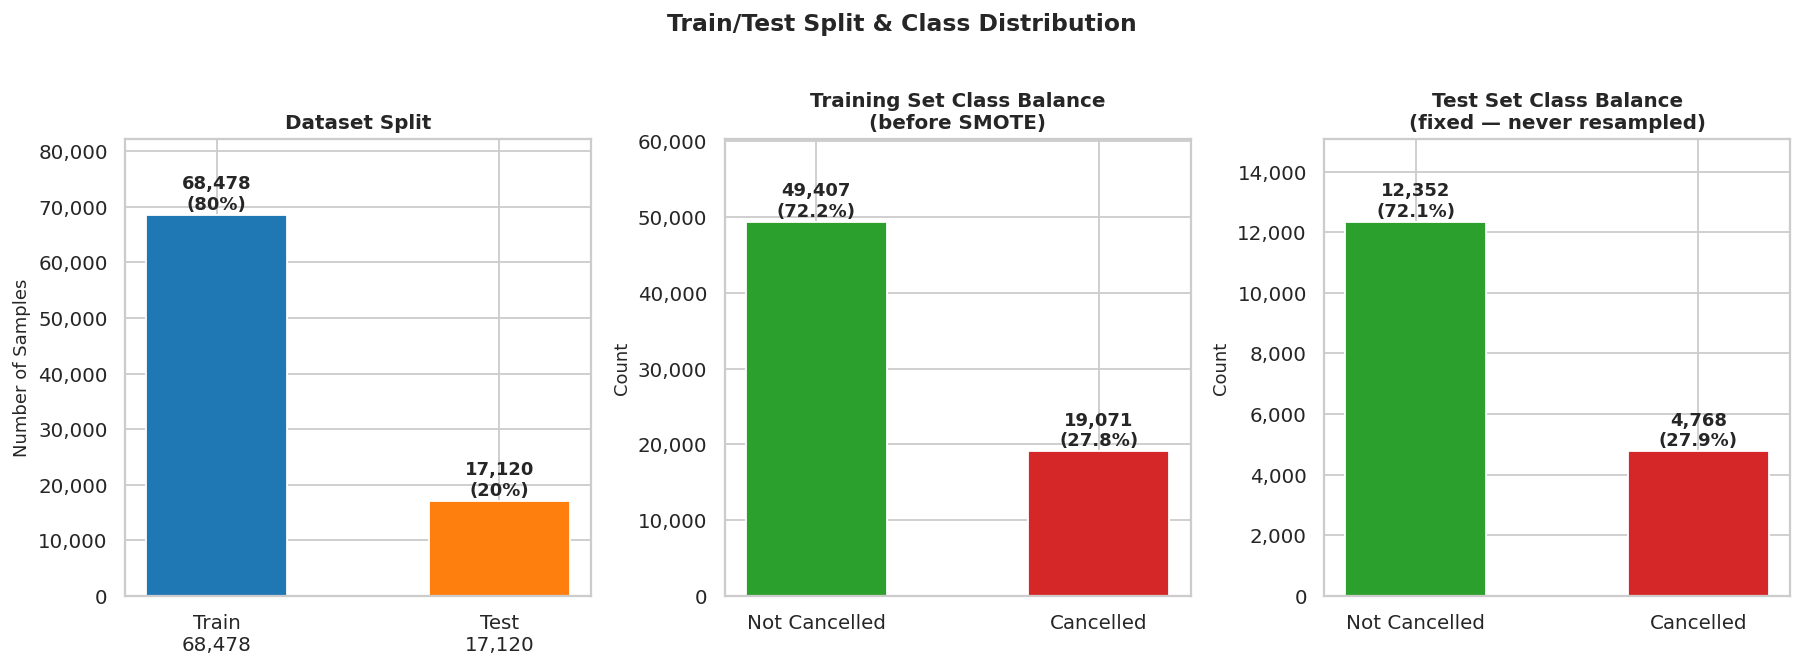

Saved -> visuals/train_test_split_balance.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Train/Test Split & Class Distribution",
             fontsize=13, fontweight="bold", y=1.02)

labels  = ["Not Cancelled", "Cancelled"]
colors  = ["#2ca02c", "#d62728"]

# ── Plot 1: Split size bars ──────────────────────────────────────────────────
split_sizes = [len(X_train), len(X_test)]
split_labels = [f"Train\n{len(X_train):,}", f"Test\n{len(X_test):,}"]
bars = axes[0].bar(split_labels, split_sizes,
                   color=["#1f77b4", "#ff7f0e"], edgecolor="white", width=0.5)
axes[0].set_title("Dataset Split", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Number of Samples", fontsize=10)
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{int(v):,}"))
for bar, val in zip(bars, split_sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 300,
                 f"{val:,}\n({val/len(X)*100:.0f}%)",
                 ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0].set_ylim(0, max(split_sizes) * 1.2)

# ── Plot 2: Training class balance ───────────────────────────────────────────
bars2 = axes[1].bar(labels, train_cnt.values,
                    color=colors, edgecolor="white", width=0.5)
axes[1].set_title("Training Set Class Balance\n(before SMOTE)",
                  fontsize=11, fontweight="bold")
axes[1].set_ylabel("Count", fontsize=10)
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{int(v):,}"))
for bar, val, pct in zip(bars2, train_cnt.values, train_dist.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f"{val:,}\n({pct*100:.1f}%)",
                 ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[1].set_ylim(0, max(train_cnt.values) * 1.22)

# ── Plot 3: Test class balance ────────────────────────────────────────────────
bars3 = axes[2].bar(labels, test_cnt.values,
                    color=colors, edgecolor="white", width=0.5)
axes[2].set_title("Test Set Class Balance\n(fixed — never resampled)",
                  fontsize=11, fontweight="bold")
axes[2].set_ylabel("Count", fontsize=10)
axes[2].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{int(v):,}"))
for bar, val, pct in zip(bars3, test_cnt.values, test_dist.values):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f"{val:,}\n({pct*100:.1f}%)",
                 ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[2].set_ylim(0, max(test_cnt.values) * 1.22)

plt.tight_layout()
plt.savefig("../visuals/train_test_split_balance.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved -> visuals/train_test_split_balance.png")


---
## Why Class Imbalance Matters for Cancellation Prediction

### The Problem

The training set is **72.15% Not Cancelled vs 27.85% Cancelled** — a 2.59:1 ratio.
This is a **moderate class imbalance**, and if left unaddressed it creates three
compounding problems for a binary classifier:

**1. Accuracy Paradox**
A model that predicts "Not Cancelled" for every booking would achieve
**72.15% accuracy** without learning anything. Accuracy is a misleading metric
for imbalanced targets — it rewards the majority class regardless of predictive power.

**2. Biased Decision Boundary**
Most algorithms (Logistic Regression, Decision Trees, SVM) minimise overall loss,
which means they are implicitly penalised more for misclassifying the majority class.
The learned decision boundary shifts toward predicting "Not Cancelled" by default,
producing high recall for class 0 but poor recall for class 1 (the class we care
most about catching).

**3. Business Cost Asymmetry**
In hotel revenue management, **false negatives are more costly than false positives**:
- **False negative:** Predict "will stay" → no overbooking protection → empty room →
  full revenue loss (£403 avg)
- **False positive:** Predict "will cancel" → activate retention offer (e.g., £15
  upgrade) → guest stays → small cost for confirmed revenue

A model that misses cancellations costs ~27× more than one that over-flags them.
The class imbalance pushes the model exactly in the wrong direction.


---
## 3 — Apply SMOTE to Training Set

In [16]:
print("Class distribution BEFORE SMOTE:")
before_cnt = pd.Series(y_train).value_counts().sort_index()
for v, n in before_cnt.items():
    label = "Not Cancelled (0)" if v == 0 else "Cancelled     (1)"
    print(f"  {label} : {n:>6,}  ({n/len(y_train)*100:.2f}%)")

# Apply SMOTE — TRAINING SET ONLY
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print()
print("Class distribution AFTER SMOTE:")
after_cnt = pd.Series(y_train_sm).value_counts().sort_index()
for v, n in after_cnt.items():
    label = "Not Cancelled (0)" if v == 0 else "Cancelled     (1)"
    print(f"  {label} : {n:>6,}  ({n/len(y_train_sm)*100:.2f}%)")

synthetic = after_cnt[1] - before_cnt[1]
print()
print(f"  Synthetic minority samples generated : {synthetic:,}")
print(f"  Training set size before SMOTE       : {len(X_train):,}")
print(f"  Training set size after  SMOTE       : {len(X_train_sm):,}")
print(f"  ✅ Test set untouched: {len(X_test):,} samples — real-world distribution preserved")


Class distribution BEFORE SMOTE:
  Not Cancelled (0) : 49,407  (72.15%)
  Cancelled     (1) : 19,071  (27.85%)



Class distribution AFTER SMOTE:
  Not Cancelled (0) : 49,407  (50.00%)
  Cancelled     (1) : 49,407  (50.00%)

  Synthetic minority samples generated : 30,336
  Training set size before SMOTE       : 68,478
  Training set size after  SMOTE       : 98,814
  ✅ Test set untouched: 17,120 samples — real-world distribution preserved


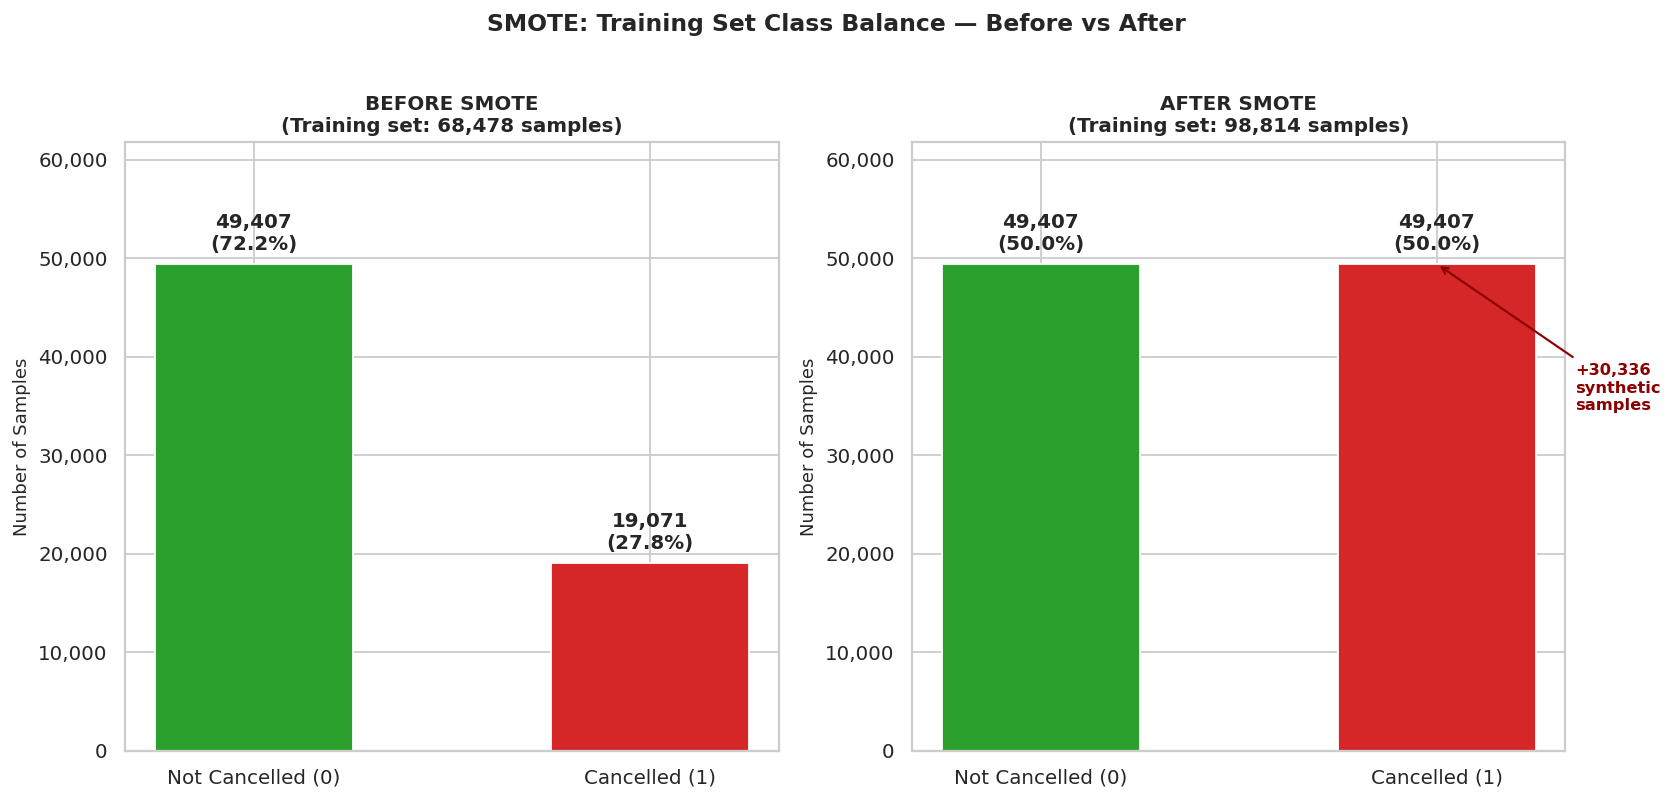

Saved -> visuals/smote_class_balance.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle("SMOTE: Training Set Class Balance — Before vs After",
             fontsize=13, fontweight="bold", y=1.02)

labels  = ["Not Cancelled (0)", "Cancelled (1)"]
colors  = ["#2ca02c", "#d62728"]

for ax, counts, title in [
    (axes[0], before_cnt,
     f"BEFORE SMOTE\n(Training set: {len(X_train):,} samples)"),
    (axes[1], after_cnt,
     f"AFTER SMOTE\n(Training set: {len(X_train_sm):,} samples)"),
]:
    bars = ax.bar(labels, counts.values, color=colors,
                  edgecolor="white", width=0.5)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("Number of Samples", fontsize=10)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.set_ylim(0, max(counts.values) * 1.25)

    for bar, val in zip(bars, counts.values):
        pct = val / counts.sum() * 100
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(counts.values) * 0.02,
                f"{val:,}\n({pct:.1f}%)",
                ha="center", va="bottom", fontsize=11, fontweight="bold")

# Annotate synthetic samples on after-SMOTE bar
synthetic_n = after_cnt[1] - before_cnt[1]
axes[1].annotate(
    f"+{synthetic_n:,}\nsynthetic\nsamples",
    xy=(1, after_cnt[1]),
    xytext=(1.35, after_cnt[1] * 0.7),
    fontsize=9, color="#8b0000", fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#8b0000", lw=1.2),
)

plt.tight_layout()
plt.savefig("../visuals/smote_class_balance.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved -> visuals/smote_class_balance.png")


---
## Why SMOTE Is Applied Only on Training Data

### How SMOTE Works

SMOTE (Synthetic Minority Oversampling Technique) generates **new synthetic samples**
for the minority class (Cancelled = 1) rather than simply duplicating existing ones.
For each minority sample, it finds its k-nearest neighbours in feature space and
creates new points along the line segments connecting them. This produces a more
diverse, generalised minority class representation than simple duplication.

In our case, SMOTE generated **30,336 synthetic cancellation records**, growing the
minority class from 19,071 to 49,407 — producing a perfectly balanced 50/50 split.

### Why Training Data Only — The Golden Rule

**The test set must always reflect the real-world class distribution.**

Applying SMOTE to the test set would corrupt the evaluation in two critical ways:

**1. Metric inflation**
Synthetic test samples are interpolated from real ones — they are not genuinely
independent observations. Evaluating on them gives falsely optimistic scores that
will not reproduce in production.

**2. Distribution shift**
In production, the model will see bookings at the real 72:28 ratio. If the test set
was artificially balanced, the evaluation would optimise for a 50:50 world that
doesn't exist — mis-calibrating thresholds and decision boundaries.

**The correct workflow:**

```
Raw data (85,598 samples, 72:28)
         │
         ├── stratified split
         │
         ├── X_train / y_train  (68,478 samples, 72:28)
         │         │
         │         └── SMOTE applied HERE ONLY
         │                   ↓
         │         X_train_sm / y_train_sm (98,814 samples, 50:50)
         │                   │
         │                   └── MODEL FITS ON THIS
         │
         └── X_test / y_test  (17,120 samples, 72:28)  ← NEVER TOUCHED
                                         │
                                         └── MODEL EVALUATED ON THIS
```

This ensures:
- The model **learns** from a balanced signal
- The model is **evaluated** against real-world conditions
- Performance metrics (AUC, F1, precision/recall) are honest estimates of
  production behaviour


---
## 4 — Save All Arrays for Model Training

In [18]:
arrays = {
    "X_train":    X_train,     # raw train features (pre-SMOTE)
    "X_test":     X_test,      # test features (never resampled)
    "y_train":    y_train,     # raw train labels (pre-SMOTE)
    "y_test":     y_test,      # test labels (real distribution)
    "X_train_sm": X_train_sm,  # SMOTE-balanced train features
    "y_train_sm": y_train_sm,  # SMOTE-balanced train labels
}

output_dir = "../data/cleaned"
os.makedirs(output_dir, exist_ok=True)

for name, arr in arrays.items():
    path = f"{output_dir}/{name}.pkl"
    with open(path, "wb") as f:
        pickle.dump(arr, f)
    size_kb = os.path.getsize(path) / 1024
    shape   = arr.shape if hasattr(arr, "shape") else (len(arr),)
    print(f"  ✅ {name:<15} saved -> {path}  | shape: {shape}  | {size_kb:.1f} KB")


  ✅ X_train         saved -> ../data/cleaned/X_train.pkl  | shape: (68478, 34)  | 18726.6 KB
  ✅ X_test          saved -> ../data/cleaned/X_test.pkl  | shape: (17120, 34)  | 4683.4 KB
  ✅ y_train         saved -> ../data/cleaned/y_train.pkl  | shape: (68478,)  | 1605.6 KB
  ✅ y_test          saved -> ../data/cleaned/y_test.pkl  | shape: (17120,)  | 401.9 KB


  ✅ X_train_sm      saved -> ../data/cleaned/X_train_sm.pkl  | shape: (98814, 34)  | 26251.2 KB
  ✅ y_train_sm      saved -> ../data/cleaned/y_train_sm.pkl  | shape: (98814,)  | 772.6 KB


In [19]:
print("=" * 60)
print("  FINAL SUMMARY — Arrays Ready for Modelling")
print("=" * 60)
print(f"  X_train    : {X_train.shape}      (pre-SMOTE train features)")
print(f"  y_train    : {y_train.shape}         (pre-SMOTE train labels)")
print(f"  X_train_sm : {X_train_sm.shape}      (SMOTE-balanced train features)")
print(f"  y_train_sm : {y_train_sm.shape}         (SMOTE-balanced train labels)")
print(f"  X_test     : {X_test.shape}      (test features — real distribution)")
print(f"  y_test     : {y_test.shape}         (test labels — real distribution)")
print()
print(f"  Training set class balance after SMOTE:")
for v, n in pd.Series(y_train_sm).value_counts().sort_index().items():
    print(f"    {v} : {n:,}  ({n/len(y_train_sm)*100:.1f}%)")
print()
print(f"  Test set class balance (unchanged):")
for v, n in pd.Series(y_test).value_counts().sort_index().items():
    print(f"    {v} : {n:,}  ({n/len(y_test)*100:.1f}%)")
print()
print("  Next: 08_model_training.ipynb")
print("=" * 60)


  FINAL SUMMARY — Arrays Ready for Modelling
  X_train    : (68478, 34)      (pre-SMOTE train features)
  y_train    : (68478,)         (pre-SMOTE train labels)
  X_train_sm : (98814, 34)      (SMOTE-balanced train features)
  y_train_sm : (98814,)         (SMOTE-balanced train labels)
  X_test     : (17120, 34)      (test features — real distribution)
  y_test     : (17120,)         (test labels — real distribution)

  Training set class balance after SMOTE:
    0 : 49,407  (50.0%)
    1 : 49,407  (50.0%)

  Test set class balance (unchanged):
    0 : 12,352  (72.1%)
    1 : 4,768  (27.9%)

  Next: 08_model_training.ipynb
